# 04 — Valutazione e risposta alle domande di ricerca

Quarto e ultimo notebook della pipeline principale. Non addestra i modelli finali: rilegge
gli esperimenti prodotti dal notebook 03 e costruisce le risposte alle tre domande.

**Input**

| percorso | prodotto da |
|---|---|
| `data/processed/battery_cycles.csv` | 01 |
| `data/processed/sequences_scarica/sequence_dataset_window10.npz` | 02 |
| `results/tables/03_metriche_per_ripetizione.csv` | 03 |
| `results/predictions/03_predizioni.csv` | 03 |
| `experiments/<esecuzione>/model.keras` | 03 |

**Struttura**

1. D1 — confronto fra architetture, con test appaiato e ablazione delle variabili.
2. D2 — condizioni operative, in cinque stadi con unità di analisi diverse.
3. D3 — robustezza fuori distribuzione, in skill score e a parità di cella.

Alcune sezioni riaddestrano modelli piccoli: l'ablazione di D1 e il guadagno condizionale
di D2. Sono modelli diagnostici, non i modelli del progetto, e le loro esecuzioni non
finiscono in `experiments/`.


## 1. Configurazione


In [1]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    IN_COLAB = True
except ImportError:
    IN_COLAB = False


def find_project_root():
    """Individua la cartella di progetto: contiene sia notebooks/ sia data/."""
    candidate_paths = [
        Path("/content/drive/MyDrive/SoH_Neural_Tracker"),
        Path("/content/drive/My Drive/SoH_Neural_Tracker"),
        Path.cwd(), *Path.cwd().parents,
    ]
    for path in candidate_paths:
        if (path / "notebooks").exists() and (path / "data").exists():
            return path
    raise FileNotFoundError(
        "Cartella di progetto non trovata. Serve una directory SoH_Neural_Tracker "
        "contenente almeno notebooks/ e data/."
    )


PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
EXPERIMENTS_DIR = PROJECT_ROOT / "experiments"
RESULTS_DIR = PROJECT_ROOT / "results"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"
PREDICTIONS_DIR = RESULTS_DIR / "predictions"
for cartella in [TABLES_DIR, FIGURES_DIR, PREDICTIONS_DIR]:
    cartella.mkdir(parents=True, exist_ok=True)

CONFIGURAZIONE = "scarica"
INSIEMI = ["train", "validation", "test_id", "test_ood"]

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

print("Radice del progetto:", PROJECT_ROOT)


Mounted at /content/drive
Radice del progetto: /content/drive/MyDrive/SoH_Neural_Tracker


In [2]:
percorso_cicli = DATA_PROCESSED / "battery_cycles.csv"
percorso_sequenze = (DATA_PROCESSED / f"sequences_{CONFIGURAZIONE}"
                     / "sequence_dataset_window10.npz")
percorso_metriche = TABLES_DIR / "03_metriche_per_ripetizione.csv"
percorso_predizioni = PREDICTIONS_DIR / "03_predizioni.csv"

for percorso, prodotto_da in [(percorso_cicli, "01_preprocessing"),
                              (percorso_sequenze, "02_sequence_preparation"),
                              (percorso_metriche, "03_training"),
                              (percorso_predizioni, "03_training")]:
    assert percorso.exists(), (
        f"manca {percorso.relative_to(PROJECT_ROOT)}: esegui prima {prodotto_da}.ipynb"
    )

df = pd.read_csv(percorso_cicli)
archivio = np.load(percorso_sequenze, allow_pickle=True)
metriche = pd.read_csv(percorso_metriche)
predizioni = pd.read_csv(percorso_predizioni)

X = {nome: archivio[f"{nome}__X"] for nome in INSIEMI}
y = {nome: archivio[f"{nome}__y"] for nome in INSIEMI}
soh_ultimo = {nome: archivio[f"{nome}__soh_ultimo"] for nome in INSIEMI}
blocco = {nome: archivio[f"{nome}__protocol_block"] for nome in INSIEMI}
batteria = {nome: archivio[f"{nome}__battery_id"] for nome in INSIEMI}
ciclo_target = {nome: archivio[f"{nome}__target_cycle"] for nome in INSIEMI}

FEATURE_NAMES = [str(v) for v in archivio["feature_names"]]
WINDOW_SIZE = int(archivio["window_size"])
MODELLI = sorted(metriche.modello.unique())

print(f"Cicli: {len(df)}   blocchi: {df.protocol_block.nunique()}")
print(f"Variabili in ingresso: {len(FEATURE_NAMES)}")
print(f"Modelli valutati: {', '.join(MODELLI)}")
for nome in INSIEMI:
    print(f"  {nome:12s} {len(y[nome]):4d} finestre")


Cicli: 1020   blocchi: 12
Variabili in ingresso: 10
Modelli valutati: GRU, LSTM, MLP, SimpleRNN
  train         316 finestre
  validation    158 finestre
  test_id       172 finestre
  test_ood      150 finestre


In [3]:
def rmse(vero, previsto):
    return float(np.sqrt(np.mean((np.asarray(previsto) - np.asarray(vero)) ** 2)))


def skill_score(vero, previsto, baseline):
    """Riduzione relativa dell'errore quadratico rispetto alla baseline.

    Vale 1 per una previsione perfetta, 0 se il modello fa come la baseline, negativo
    se fa peggio. È quadratico: un errore doppio della baseline dà -3, non -1.
    """
    mse_modello = np.mean((np.asarray(previsto) - np.asarray(vero)) ** 2)
    mse_baseline = np.mean((np.asarray(baseline) - np.asarray(vero)) ** 2)
    return float(1.0 - mse_modello / mse_baseline) if mse_baseline else np.nan


baseline_rmse = {nome: rmse(y[nome], soh_ultimo[nome]) for nome in INSIEMI}
print("Errore della persistenza, per insieme:")
for nome, valore in baseline_rmse.items():
    print(f"  {nome:12s} {valore:.5f}")


Errore della persistenza, per insieme:
  train        0.00989
  validation   0.00675
  test_id      0.01103
  test_ood     0.00804


# D1 — Confronto fra architetture

> *Quale architettura neurale prevede meglio il SoH del ciclo successivo a partire da una
> finestra di dieci cicli, e quanto si distingue da una baseline naive che si limita a
> ripetere l'ultimo valore osservato?*

La domanda ha due parti e vanno tenute separate: **quale architettura vince fra loro**, e
**se una qualsiasi batta il riferimento naive**. Sono due confronti diversi e possono avere
esito opposto.


## 2. Il confronto fra i quattro modelli

Ogni architettura è stata addestrata dieci volte cambiando solo il seme. Riporto mediana e
scarto interquartile invece di media e deviazione standard: con dieci ripetizioni una
singola esecuzione andata male sposta la media di molto, e ciò che interessa è il
comportamento tipico.


In [4]:
def riepiloga(insieme):
    tabella = (metriche[metriche.insieme == insieme]
               .groupby("modello")
               .agg(RMSE_mediana=("RMSE", "median"),
                    RMSE_q1=("RMSE", lambda s: s.quantile(0.25)),
                    RMSE_q3=("RMSE", lambda s: s.quantile(0.75)),
                    MAE_mediana=("MAE", "median"),
                    SS_mediana=("SS", "median"),
                    epoche_mediana=("epoche", "median"))
               .reset_index())
    tabella["RMSE_iqr"] = tabella.RMSE_q3 - tabella.RMSE_q1
    tabella["rapporto_baseline"] = tabella.RMSE_mediana / baseline_rmse[insieme]
    return tabella.sort_values("RMSE_mediana").reset_index(drop=True)


for insieme in ["validation", "test_id", "test_ood"]:
    print(f"\n{insieme}   (persistenza: RMSE {baseline_rmse[insieme]:.5f})")
    display(riepiloga(insieme)[["modello", "RMSE_mediana", "RMSE_iqr", "MAE_mediana",
                                "SS_mediana", "rapporto_baseline", "epoche_mediana"]]
            .round(5))

d1_riepilogo = riepiloga("test_id")
d1_riepilogo.to_csv(TABLES_DIR / "04_d1_riepilogo_test_id.csv", index=False)



validation   (persistenza: RMSE 0.00675)


,modello,RMSE_mediana,RMSE_iqr,MAE_mediana,SS_mediana,rapporto_baseline,epoche_mediana
0,LSTM,0.02326,0.01079,0.01793,-10.92166,3.44424,92.0
1,GRU,0.02822,0.01836,0.02347,-16.47531,4.17946,76.0
2,SimpleRNN,0.03186,0.03862,0.01642,-21.75939,4.71804,150.0
3,MLP,0.09177,0.04483,0.06787,-184.46285,13.59164,150.0



test_id   (persistenza: RMSE 0.01103)


,modello,RMSE_mediana,RMSE_iqr,MAE_mediana,SS_mediana,rapporto_baseline,epoche_mediana
0,SimpleRNN,0.02680,0.03861,0.01939,-5.34035,2.43025,150.0
1,GRU,0.03315,0.02639,0.02601,-8.04375,3.00660,76.0
2,LSTM,0.04576,0.03029,0.03551,-16.28087,4.15069,92.0
3,MLP,0.10210,0.05707,0.08274,-85.04494,9.26043,150.0



test_ood   (persistenza: RMSE 0.00804)


,modello,RMSE_mediana,RMSE_iqr,MAE_mediana,SS_mediana,rapporto_baseline,epoche_mediana
0,SimpleRNN,0.01776,0.03553,0.01410,-4.48820,2.20866,150.0
1,LSTM,0.02922,0.00960,0.02167,-12.24528,3.63329,92.0
2,GRU,0.03027,0.01755,0.02304,-13.39742,3.76409,76.0
3,MLP,0.08378,0.04364,0.06897,-108.31062,10.41701,150.0


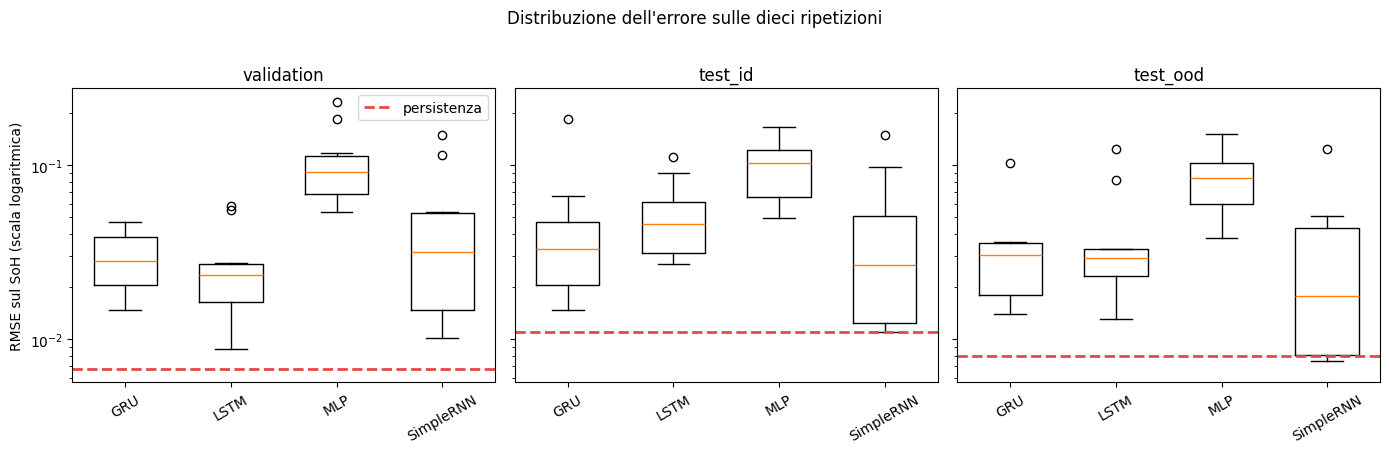

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), sharey=True)

for ax, insieme in zip(axes, ["validation", "test_id", "test_ood"]):
    dati = [metriche[(metriche.modello == m) & (metriche.insieme == insieme)].RMSE.values
            for m in MODELLI]
    ax.boxplot(dati, tick_labels=MODELLI, widths=0.6)
    # La baseline non ha variabilità: è una riga, non una distribuzione.
    ax.axhline(baseline_rmse[insieme], color="#e34948", lw=2, ls="--",
               label="persistenza")
    ax.set_title(insieme)
    ax.set_yscale("log")
    ax.tick_params(axis="x", rotation=30)

axes[0].set_ylabel("RMSE sul SoH (scala logaritmica)")
axes[0].legend()
fig.suptitle("Distribuzione dell'errore sulle dieci ripetizioni", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_d1_distribuzione_errore.png", dpi=200, bbox_inches="tight")
plt.show()


La scala verticale è logaritmica perché i modelli differiscono di un ordine di grandezza e
su scala lineare le differenze fra i tre ricorrenti sarebbero schiacciate contro l'asse.


## 3. Le differenze fra architetture sono reali?

I modelli condividono i semi, quindi le ripetizioni sono appaiate: per ogni coppia si
prendono le dieci differenze di RMSE e si applica il test dei ranghi con segno di Wilcoxon.

Il test è appaiato e non parametrico. Appaiato perché confrontare due medie indipendenti
butterebbe via l'informazione che le esecuzioni condividono l'inizializzazione, e con
questa variabilità perderebbe quasi ogni potere. Non parametrico perché non ho motivo di
assumere che le differenze di RMSE siano normali, e con dieci osservazioni non potrei
verificarlo.


In [6]:
from scipy.stats import wilcoxon

valori = (metriche[metriche.insieme == "test_id"]
          .pivot_table(index="seme", columns="modello", values="RMSE"))
n_ripetizioni = len(valori)

# Con n osservazioni il valore p minimo ottenibile dal test dei ranghi con segno è
# 2/2^n: sotto sei ripetizioni nessuna differenza può risultare significativa al 5%.
assert n_ripetizioni >= 6, (
    f"{n_ripetizioni} ripetizioni: il test dei ranghi con segno non può raggiungere "
    "la significatività al cinque per cento"
)

coppie = []
for i, primo in enumerate(MODELLI):
    for secondo in MODELLI[i + 1:]:
        differenze = (valori[primo] - valori[secondo]).dropna()
        coppie.append({
            "modello_A": primo, "modello_B": secondo,
            "RMSE_A": float(valori[primo].median()),
            "RMSE_B": float(valori[secondo].median()),
            "differenza_mediana": float(differenze.median()),
            "vittorie_A": int((differenze < 0).sum()),
            "p": float(wilcoxon(differenze).pvalue),
        })

coppie = pd.DataFrame(coppie)
coppie["significativa"] = coppie.p < 0.05
coppie["migliore"] = np.where(coppie.differenza_mediana < 0,
                              coppie.modello_A, coppie.modello_B)
coppie.loc[~coppie.significativa, "migliore"] = "indistinguibili"

display(coppie.round(5))
coppie.to_csv(TABLES_DIR / "04_d1_confronti_appaiati.csv", index=False)

print(f"\nSu {n_ripetizioni} ripetizioni, il p minimo ottenibile è "
      f"{2 / 2 ** n_ripetizioni:.4f}.")
print("Coppie con differenza significativa al 5%:",
      int(coppie.significativa.sum()), "su", len(coppie))


,modello_A,modello_B,RMSE_A,RMSE_B,differenza_mediana,vittorie_A,p,significativa,migliore
0,GRU,LSTM,0.03315,0.04576,-0.01011,8,0.23242,False,indistinguibili
1,GRU,MLP,0.03315,0.10210,-0.06831,9,0.01367,True,GRU
2,GRU,SimpleRNN,0.03315,0.02680,0.00769,3,0.76953,False,indistinguibili
3,LSTM,MLP,0.04576,0.10210,-0.06337,9,0.01953,True,LSTM
4,LSTM,SimpleRNN,0.04576,0.02680,0.02030,3,0.32227,False,indistinguibili
5,MLP,SimpleRNN,0.10210,0.02680,0.07677,2,0.04883,True,SimpleRNN



Su 10 ripetizioni, il p minimo ottenibile è 0.0020.
Coppie con differenza significativa al 5%: 3 su 6


## 4. Nessun modello batte la persistenza: perché

Il confronto con il riferimento naive ha esito negativo, e la spiegazione non è che i
modelli siano mal costruiti. La si legge da tre osservazioni che vanno guardate insieme.


In [7]:
# 1. Di quanto cambia il SoH da un ciclo al successivo: è la grandezza da prevedere.
variazioni = {nome: y[nome] - soh_ultimo[nome] for nome in INSIEMI}

# 2. La seconda baseline: retta ai minimi quadrati sui dieci SoH della finestra,
#    prolungata di un ciclo. Usa tutta la finestra, come i modelli neurali.
indice_soh = FEATURE_NAMES.index("soh_feature")
passi = np.arange(WINDOW_SIZE)


def estrapola_retta(finestre_soh, orizzonte=1):
    pendenza, intercetta = np.polyfit(passi, finestre_soh.T, 1)
    return pendenza * (passi[-1] + orizzonte) + intercetta


retta = {nome: estrapola_retta(X[nome][:, :, indice_soh]) for nome in INSIEMI}

confronto_baseline = pd.DataFrame([{
    "insieme": nome,
    "n_finestre": len(y[nome]),
    "variazione_media": float(variazioni[nome].mean()),
    "variazione_sd": float(variazioni[nome].std()),
    "persistenza_RMSE": baseline_rmse[nome],
    "retta_RMSE": rmse(y[nome], retta[nome]),
    "retta_SS": skill_score(y[nome], retta[nome], soh_ultimo[nome]),
} for nome in INSIEMI])

display(confronto_baseline.round(5))
confronto_baseline.to_csv(TABLES_DIR / "04_d1_baseline.csv", index=False)


,insieme,n_finestre,variazione_media,variazione_sd,persistenza_RMSE,retta_RMSE,retta_SS
0,train,316,-0.00207,0.00967,0.00989,0.01274,-0.65881
1,validation,158,-0.00147,0.00659,0.00675,0.00773,-0.30940
2,test_id,172,-0.00236,0.01077,0.01103,0.01324,-0.44095
3,test_ood,150,-0.00334,0.00732,0.00804,0.00799,0.01242


In [8]:
peggiore = confronto_baseline[confronto_baseline.retta_SS < 0]
migliore_neurale = d1_riepilogo.iloc[0]

print("Lettura del risultato\n")
print(f"1. La variazione da prevedere ha deviazione standard "
      f"{variazioni['test_id'].std():.5f} sul test in distribuzione: è la scala del "
      f"segnale.")
print(f"2. La persistenza sbaglia di {baseline_rmse['test_id']:.5f}, cioè dello stesso "
      f"ordine: sta già al livello del rumore di misura.")
print(f"3. La retta sulla finestra sbaglia di "
      f"{float(confronto_baseline.set_index('insieme').loc['test_id', 'retta_RMSE']):.5f}, "
      f"quindi {'peggio' if len(peggiore) else 'meglio'} della persistenza "
      f"su {len(peggiore)} insiemi su {len(confronto_baseline)}.")
print()
print(f"Il miglior modello neurale è {migliore_neurale.modello} con RMSE "
      f"{migliore_neurale.RMSE_mediana:.5f}, pari a "
      f"{migliore_neurale.rapporto_baseline:.1f} volte la persistenza.")
print()
print("Se un metodo lineare a due parametri stimati non batte una regola a zero")
print("parametri, il limite non è la capacità del modello ma il rapporto fra segnale")
print("sistematico e rumore del bersaglio a un ciclo di distanza. È una proprietà del")
print("compito, e la verifica diretta è l'esperimento sull'orizzonte di previsione.")


Lettura del risultato

1. La variazione da prevedere ha deviazione standard 0.01077 sul test in distribuzione: è la scala del segnale.
2. La persistenza sbaglia di 0.01103, cioè dello stesso ordine: sta già al livello del rumore di misura.
3. La retta sulla finestra sbaglia di 0.01324, quindi peggio della persistenza su 3 insiemi su 4.

Il miglior modello neurale è SimpleRNN con RMSE 0.02680, pari a 2.4 volte la persistenza.

Se un metodo lineare a due parametri stimati non batte una regola a zero
parametri, il limite non è la capacità del modello ma il rapporto fra segnale
sistematico e rumore del bersaglio a un ciclo di distanza. È una proprietà del
compito, e la verifica diretta è l'esperimento sull'orizzonte di previsione.


## 5. Ablazione: quali variabili contano davvero

Si riaddestra il modello migliore togliendo un gruppo di variabili per volta e si misura
di quanto peggiora. È diverso dalla permutation importance della sezione D2: qui il
modello viene **riaddestrato** senza quelle variabili, quindi può riorganizzarsi e usare
le altre. Misura l'informazione che il gruppo porta *in più* rispetto al resto, non
quanto il modello addestrato vi si appoggia.

Tre semi per configurazione: bastano a distinguere un effetto grande dal rumore, e
l'ablazione non deve competere in precisione con le dieci ripetizioni del notebook 03.


In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

SEMI_ABLAZIONE = [0, 1, 2]
UNITA, UNITA_DENSA, DROPOUT = 64, 32, 0.2

GRUPPI_VARIABILI = {
    "tutte": [],
    "senza SoH": ["soh_feature"],
    "senza tensione": [c for c in FEATURE_NAMES if c.startswith("voltage")],
    "senza temperatura": [c for c in FEATURE_NAMES if c.startswith("temperature")],
    "senza durata": [c for c in FEATURE_NAMES
                     if c.startswith(("discharge_time", "num_measurements"))],
}

MODELLO_MIGLIORE = d1_riepilogo.iloc[0].modello
print("Architettura usata per l'ablazione:", MODELLO_MIGLIORE)
for nome, escluse in GRUPPI_VARIABILI.items():
    print(f"  {nome:20s} toglie {len(escluse):2d} variabili: {', '.join(escluse) or '—'}")


Architettura usata per l'ablazione: SimpleRNN
  tutte                toglie  0 variabili: —
  senza SoH            toglie  1 variabili: soh_feature
  senza tensione       toglie  4 variabili: voltage_mean_rel, voltage_min_rel, voltage_max_rel, voltage_std_rel
  senza temperatura    toglie  3 variabili: temperature_mean_rise_rel, temperature_max_rise_rel, temperature_std_rel
  senza durata         toglie  2 variabili: discharge_time_rel, num_measurements_rel


In [10]:
def costruisci(nome_modello, forma, bias_iniziale):
    ingresso = layers.Input(shape=forma)
    if nome_modello == "MLP":
        x = layers.Flatten()(ingresso)
        x = layers.Dense(UNITA, activation="relu")(x)
    else:
        strato = {"SimpleRNN": layers.SimpleRNN, "LSTM": layers.LSTM,
                  "GRU": layers.GRU}[nome_modello]
        x = strato(UNITA)(ingresso)
    x = layers.Dropout(DROPOUT)(x)
    x = layers.Dense(UNITA_DENSA, activation="relu")(x)
    uscita = layers.Dense(
        1, bias_initializer=tf.keras.initializers.Constant(bias_iniziale))(x)
    return models.Model(ingresso, uscita)


def addestra_e_valuta(nome_modello, colonne, semi, epoche=150, pazienza=20):
    """Addestra sul sottoinsieme di variabili indicato e restituisce l'RMSE per seme.

    Il bersaglio è la variazione del SoH, come nel notebook 03: la previsione finale è
    l'ultimo valore osservato più la variazione prevista.
    """
    indici = [FEATURE_NAMES.index(c) for c in colonne]
    Xs = {nome: X[nome][:, :, indici] for nome in INSIEMI}
    ts = {nome: y[nome] - soh_ultimo[nome] for nome in INSIEMI}

    righe = []
    for seme in semi:
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(seme)

        modello = costruisci(nome_modello, Xs["train"].shape[1:], float(ts["train"].mean()))
        modello.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
        modello.fit(Xs["train"], ts["train"],
                    validation_data=(Xs["validation"], ts["validation"]),
                    epochs=epoche, batch_size=32, verbose=0,
                    callbacks=[callbacks.EarlyStopping(monitor="val_loss",
                                                       patience=pazienza,
                                                       restore_best_weights=True)])

        for nome in INSIEMI:
            previsto = modello.predict(Xs[nome], verbose=0).reshape(-1) + soh_ultimo[nome]
            righe.append({"seme": seme, "insieme": nome,
                          "RMSE": rmse(y[nome], previsto),
                          "SS": skill_score(y[nome], previsto, soh_ultimo[nome])})
    return pd.DataFrame(righe)


In [11]:
righe_ablazione = []
for etichetta, escluse in GRUPPI_VARIABILI.items():
    colonne = [c for c in FEATURE_NAMES if c not in escluse]
    if not colonne:
        continue
    risultato = addestra_e_valuta(MODELLO_MIGLIORE, colonne, SEMI_ABLAZIONE)
    risultato["configurazione"] = etichetta
    risultato["n_variabili"] = len(colonne)
    righe_ablazione.append(risultato)
    mediana = risultato[risultato.insieme == "test_id"].RMSE.median()
    print(f"{etichetta:20s} {len(colonne):2d} variabili   RMSE test_id {mediana:.5f}")

ablazione = pd.concat(righe_ablazione, ignore_index=True)
ablazione.to_csv(TABLES_DIR / "04_d1_ablazione_per_seme.csv", index=False)


tutte                10 variabili   RMSE test_id 0.01161
senza SoH             9 variabili   RMSE test_id 0.02841
senza tensione        6 variabili   RMSE test_id 0.01563
senza temperatura     7 variabili   RMSE test_id 0.01546
senza durata          8 variabili   RMSE test_id 0.01927


In [12]:
riepilogo_ablazione = (ablazione[ablazione.insieme == "test_id"]
                       .groupby(["configurazione", "n_variabili"])
                       .agg(RMSE_mediana=("RMSE", "median"),
                            RMSE_min=("RMSE", "min"), RMSE_max=("RMSE", "max"))
                       .reset_index())

riferimento = float(riepilogo_ablazione
                    .set_index("configurazione").loc["tutte", "RMSE_mediana"])
riepilogo_ablazione["peggioramento"] = (
    riepilogo_ablazione.RMSE_mediana / riferimento - 1.0)

display(riepilogo_ablazione.sort_values("RMSE_mediana").round(5))
riepilogo_ablazione.to_csv(TABLES_DIR / "04_d1_ablazione.csv", index=False)

print("\nIl peggioramento è relativo alla configurazione con tutte le variabili.")
print("Valori vicini a zero indicano gruppi la cui informazione è già contenuta")
print("altrove; valori grandi indicano gruppi non sostituibili.")


,configurazione,n_variabili,RMSE_mediana,RMSE_min,RMSE_max,peggioramento
4,tutte,10,0.01161,0.01069,0.02271,0.00000
2,senza temperatura,7,0.01546,0.01070,0.02363,0.33226
3,senza tensione,6,0.01563,0.01452,0.02615,0.34689
1,senza durata,8,0.01927,0.01081,0.03542,0.66068
0,senza SoH,9,0.02841,0.01358,0.03046,1.44774



Il peggioramento è relativo alla configurazione con tutte le variabili.
Valori vicini a zero indicano gruppi la cui informazione è già contenuta
altrove; valori grandi indicano gruppi non sostituibili.


# D2 — Condizioni operative e velocità di degrado

> *Quali condizioni operative sono associate a un degrado più rapido, e quali di esse
> rappresentano uno stress operativo anziché una conseguenza del degrado già avvenuto?*

## 6. Perché serve più di uno screening di correlazione

Il modo diretto di rispondere sarebbe calcolare la correlazione fra ciascuna variabile e
il SoH su tutti i cicli. Non funziona, per tre ragioni indipendenti: ciascuna, da sola,
rende il risultato non interpretabile.

**L'unità di analisi.** La temperatura ambiente non varia dentro un blocco: varia solo fra
blocchi. Calcolarne la correlazione su novecento cicli significa contare novecento volte
quattro condizioni sperimentali. Il numero che esce ha un intervallo di confidenza stretto
perché $n$ è grande, ma l'informazione vera nel campione è $n = 12$ blocchi.

**Causa e conseguenza.** La temperatura di scarica cresce quando cresce la resistenza
interna, cioè quando la cella è già degradata. La correlazione con il SoH è forte, ma il
verso della freccia è opposto a quello che si vorrebbe leggere.

**La non monotonia.** Il degrado ha un minimo a temperatura intermedia e cresce sia
scaldando sia raffreddando. Una relazione non monotona ha correlazione lineare vicina a
zero o di segno arbitrario, a seconda di come sono bilanciati i gruppi nel campione.

Le tre difficoltà si affrontano con strumenti diversi, e ciascuno stadio che segue ne
affronta una.


In [13]:
# Quantificazione della prima difficoltà: quanta informazione c'è davvero nel campione.
validi = df[df.is_valid].copy()

confronto_unita = []
for variabile in ["ambient_temperature", "current_mean", "temperature_max"]:
    entro = validi.groupby("protocol_block")[variabile].std().mean()
    fra = validi.groupby("protocol_block")[variabile].mean().std()
    confronto_unita.append({
        "variabile": variabile,
        "sd_media_entro_blocco": entro,
        "sd_fra_blocchi": fra,
        "quota_entro": entro / (entro + fra) if (entro + fra) else 0.0,
        "n_cicli": len(validi),
        "n_blocchi": validi.protocol_block.nunique(),
    })

confronto_unita = pd.DataFrame(confronto_unita)
display(confronto_unita.round(4))
confronto_unita.to_csv(TABLES_DIR / "04_d2_unita_di_analisi.csv", index=False)

print("Una variabile con quota_entro vicina a zero non varia dentro il blocco: la sua")
print("unità di analisi è il blocco, e le osservazioni indipendenti sono",
      validi.protocol_block.nunique(), "e non", len(validi))


,variabile,sd_media_entro_blocco,sd_fra_blocchi,quota_entro,n_cicli,n_blocchi
0,ambient_temperature,0.0000,14.0346,0.0000,926,12
1,current_mean,0.0455,1.1435,0.0383,926,12
2,temperature_max,0.6703,17.6375,0.0366,926,12


Una variabile con quota_entro vicina a zero non varia dentro il blocco: la sua
unità di analisi è il blocco, e le osservazioni indipendenti sono 12 e non 926


## 7. Stadio 1a — fattori di protocollo, unità: il blocco

Per ogni blocco si stima il tasso di degrado come pendenza del SoH rispetto al numero di
ciclo, ai minimi quadrati e sui soli cicli validi. La regressione è preferita alla
differenza fra primo e ultimo valore, che dipenderebbe da due sole osservazioni.

**La finestra comune.** I blocchi sono osservati per un numero molto diverso di cicli, e
il degrado accelera a fine vita: su finestre disuguali il confronto sfavorisce
sistematicamente chi è osservato più a lungo. Il calcolo viene quindi ripetuto su una
finestra iniziale uguale per tutti, e la conclusione si appoggia su quella.


In [14]:
def tasso_di_degrado(dati, n_finestra=None):
    """Perdita di SoH in punti percentuali ogni cento cicli, per blocco di protocollo."""
    righe = []
    for blocco_id, gruppo in dati[dati.is_valid].groupby("protocol_block"):
        gruppo = gruppo.sort_values("discharge_cycle")
        if n_finestra is not None:
            gruppo = gruppo.head(n_finestra)
            if len(gruppo) < n_finestra:
                continue
        if len(gruppo) < 10:
            continue
        pendenza = np.polyfit(gruppo.discharge_cycle, gruppo.soh, 1)[0]
        righe.append({
            "protocol_block": blocco_id,
            "battery_id": gruppo.battery_id.iloc[0],
            "ambiente_c": float(gruppo.ambient_temperature.iloc[0]),
            "corrente_a": round(float(gruppo.current_mean.abs().median()), 2),
            "n_cicli_usati": len(gruppo),
            "fade_pct_per_100": -pendenza * 100 * 100,
        })
    return (pd.DataFrame(righe)
            .sort_values(["ambiente_c", "protocol_block"]).reset_index(drop=True))


# La finestra comune è la lunghezza del blocco più corto: più lunga escluderebbe blocchi.
lunghezze = (df[df.is_valid].groupby("protocol_block").size())
FINESTRA_COMUNE = int(lunghezze.min())
print(f"Blocco più corto: {FINESTRA_COMUNE} cicli validi "
      f"({lunghezze.idxmin()}). È la finestra comune.")

tassi_completi = tasso_di_degrado(df)
tassi_comuni = tasso_di_degrado(df, n_finestra=FINESTRA_COMUNE)

display(tassi_comuni.round(2))
tassi_comuni.to_csv(TABLES_DIR / "04_d2_tasso_degrado_per_blocco.csv", index=False)


Blocco più corto: 25 cicli validi (B0042_p2). È la finestra comune.


,protocol_block,battery_id,ambiente_c,corrente_a,n_cicli_usati,fade_pct_per_100
0,B0042_p2,B0042,4.0,1.00,25,42.93
1,B0043_p2,B0043,4.0,0.97,25,69.79
2,B0042_p1,B0042,22.0,2.00,25,19.84
3,B0043_p1,B0043,22.0,1.91,25,33.29
4,B0005_p1,B0005,24.0,1.87,25,4.27
5,B0006_p1,B0006,24.0,1.99,25,25.27
6,B0007_p1,B0007,24.0,1.93,25,3.82
7,B0018_p1,B0018,24.0,1.92,25,32.31
8,B0029_p1,B0029,43.0,3.95,25,23.79
9,B0030_p1,B0030,43.0,3.78,25,26.34


In [15]:
def per_gruppo(tassi, etichetta):
    return (tassi.groupby("ambiente_c")
            .agg(n_blocchi=("protocol_block", "count"),
                 mediana=("fade_pct_per_100", "median"),
                 minimo=("fade_pct_per_100", "min"),
                 massimo=("fade_pct_per_100", "max"))
            .round(2).reset_index().assign(finestra=etichetta))


gruppi = pd.concat([
    per_gruppo(tassi_completi, "completa"),
    per_gruppo(tassi_comuni, f"comune ({FINESTRA_COMUNE} cicli)"),
], ignore_index=True)

display(gruppi)
gruppi.to_csv(TABLES_DIR / "04_d2_tasso_degrado_per_gruppo.csv", index=False)

# Nessun valore p fra gruppi di due blocchi: con due osservazioni non si fa inferenza.
piccoli = gruppi[gruppi.n_blocchi < 3].ambiente_c.unique()
if len(piccoli):
    print("\nGruppi con meno di tre blocchi:", ", ".join(f"{t:.0f} °C" for t in piccoli))
    print("Per questi si riportano direzione e intervallo osservato, non test statistici:")
    print("con due osservazioni qualsiasi test avrebbe potenza trascurabile.")


,ambiente_c,n_blocchi,mediana,minimo,massimo,finestra
0,4.0,2,56.36,42.93,69.79,completa
1,22.0,2,27.13,21.72,32.54,completa
2,24.0,4,21.20,17.38,25.26,completa
3,43.0,4,27.98,17.56,28.61,completa
4,4.0,2,56.36,42.93,69.79,comune (25 cicli)
5,22.0,2,26.56,19.84,33.29,comune (25 cicli)
6,24.0,4,14.77,3.82,32.31,comune (25 cicli)
7,43.0,4,24.68,12.67,26.34,comune (25 cicli)



Gruppi con meno di tre blocchi: 4 °C, 22 °C
Per questi si riportano direzione e intervallo osservato, non test statistici:
con due osservazioni qualsiasi test avrebbe potenza trascurabile.


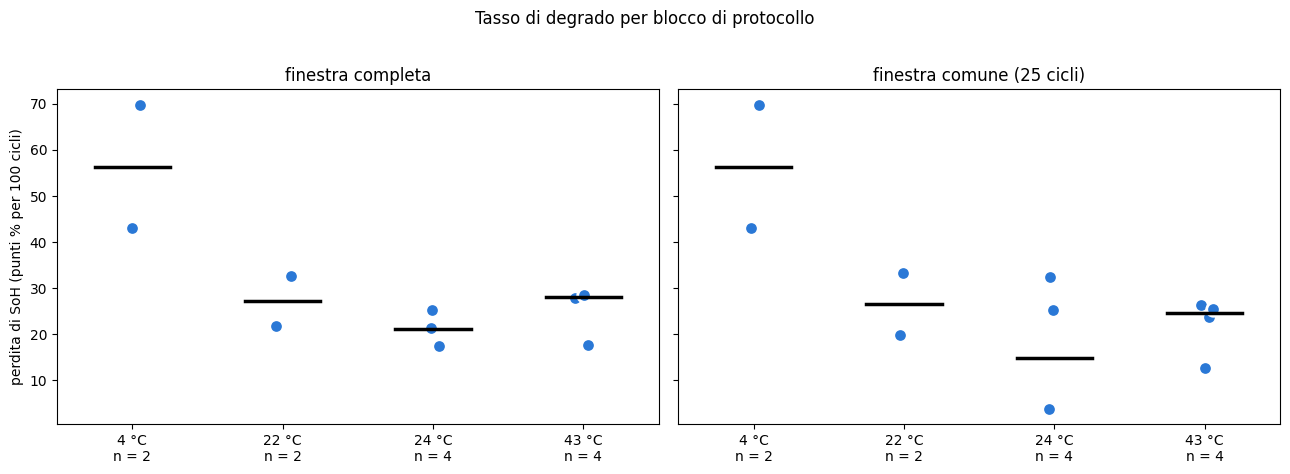

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
rng = np.random.default_rng(1)

for ax, (tassi, titolo) in zip(axes, [
    (tassi_completi, "finestra completa"),
    (tassi_comuni, f"finestra comune ({FINESTRA_COMUNE} cicli)"),
]):
    temperature = sorted(tassi.ambiente_c.unique())
    for i, temperatura in enumerate(temperature):
        sotto = tassi[tassi.ambiente_c == temperatura]
        # Un punto per blocco: l'ampiezza campionaria resta visibile a chi legge.
        ax.scatter(i + rng.uniform(-0.06, 0.06, len(sotto)), sotto.fade_pct_per_100,
                   s=95, color="#2a78d6", edgecolor="white", linewidth=2, zorder=3)
        mediana = sotto.fade_pct_per_100.median()
        ax.plot([i - 0.25, i + 0.25], [mediana, mediana], color="black", lw=2.5, zorder=4)
    ax.set_xticks(range(len(temperature)))
    ax.set_xticklabels([f"{t:.0f} °C\nn = {(tassi.ambiente_c == t).sum()}"
                        for t in temperature])
    ax.set_xlim(-0.5, len(temperature) - 0.5)
    ax.set_title(titolo)

axes[0].set_ylabel("perdita di SoH (punti % per 100 cicli)")
fig.suptitle("Tasso di degrado per blocco di protocollo", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_d2_tasso_degrado.png", dpi=200, bbox_inches="tight")
plt.show()


### Il confondimento fra temperatura e corrente

La tabella dei protocolli mostra che i due fattori non variano in modo indipendente. Se a
ogni livello di temperatura corrisponde un solo livello di corrente, i due effetti non
sono separabili con questi dati, qualunque statistica si usi.


In [17]:
incrocio = (validi.groupby("protocol_block")
            .agg(ambiente=("ambient_temperature", "first"),
                 corrente=("current_mean", lambda s: round(float(s.abs().median()))))
            .reset_index()
            .pivot_table(index="ambiente", columns="corrente",
                         values="protocol_block", aggfunc="count", fill_value=0))
display(incrocio)

celle_piene = int((incrocio.to_numpy() > 0).sum())
print(f"Combinazioni temperatura × corrente osservate: {celle_piene} "
      f"su {incrocio.size} possibili.")
if celle_piene <= max(incrocio.shape):
    print("Il disegno è completamente confuso: a ogni temperatura corrisponde una sola")
    print("corrente. L'effetto attribuibile alla sola temperatura non è identificabile,")
    print("e ciò che si misura è l'effetto del protocollo nel suo complesso.")


corrente,1,2,4
ambiente,,,
4.0,2,0,0
22.0,0,2,0
24.0,0,4,0
43.0,0,0,4


Combinazioni temperatura × corrente osservate: 4 su 12 possibili.
Il disegno è completamente confuso: a ogni temperatura corrisponde una sola
corrente. L'effetto attribuibile alla sola temperatura non è identificabile,
e ciò che si misura è l'effetto del protocollo nel suo complesso.


## 8. Stadio 1b — variabili entro blocco: permutation importance

Per le variabili che cambiano dentro un blocco l'unità di analisi è la finestra, e lo
strumento è il modello addestrato.

Si permuta casualmente una variabile fra i campioni di valutazione, lasciando tutto il
resto invariato, e si misura di quanto cresce l'errore. Se la variabile è inutile l'errore
non cambia; se è essenziale, cresce molto.

Due dettagli che determinano cosa si sta misurando. La permutazione è **fra finestre** e
non dentro la finestra: permutando dentro si distruggerebbe anche la struttura temporale
della variabile, e non si misurerebbe più la sola informazione che porta. E la stessa
permutazione si applica a **tutti i passi** della finestra, perché la variabile è una sola
grandezza osservata dieci volte, non dieci variabili distinte.

Venti ripetizioni per ottenere media e dispersione: una singola permutazione è essa stessa
un'estrazione casuale.


In [18]:
N_PERMUTAZIONI = 20

cartelle_esperimenti = sorted(
    [c for c in EXPERIMENTS_DIR.iterdir()
     if c.is_dir() and (c / "model.keras").exists()],
    key=lambda c: c.name)
assert cartelle_esperimenti, "nessun modello salvato in experiments/: esegui il notebook 03"

# Si usa il modello dell'architettura migliore, dall'esecuzione più recente.
candidati = [c for c in cartelle_esperimenti
             if c.name.endswith(MODELLO_MIGLIORE.lower())]
assert candidati, f"nessuna cartella per {MODELLO_MIGLIORE} in experiments/"
cartella_modello = candidati[-1]

modello_valutato = tf.keras.models.load_model(cartella_modello / "model.keras")
configurazione = json.loads((cartella_modello / "config.json").read_text())

print("Modello:", cartella_modello.name)
print("Variabili:", len(configurazione["variabili"]))
print("Grandezza prevista:", configurazione.get("grandezza_prevista", "SoH"))
assert configurazione["variabili"] == FEATURE_NAMES, (
    "il modello salvato usa variabili diverse da quelle del dataset caricato"
)


Modello: 20260830_1504_simplernn
Variabili: 10
Grandezza prevista: variazione del SoH rispetto all'ultimo ciclo osservato


In [19]:
def permutation_importance(modello, Xa, y_vero, ultimo, n_permutazioni=N_PERMUTAZIONI,
                           seme=0):
    """Aumento di errore quando una variabile viene permutata fra le finestre."""
    rng = np.random.default_rng(seme)
    base = rmse(y_vero, modello.predict(Xa, verbose=0).reshape(-1) + ultimo)

    righe = []
    for j, nome_variabile in enumerate(FEATURE_NAMES):
        aumenti = []
        for _ in range(n_permutazioni):
            Xp = Xa.copy()
            # Stessa permutazione su tutti i passi: la variabile è una sola grandezza
            # osservata dieci volte, non dieci variabili distinte.
            Xp[:, :, j] = Xa[rng.permutation(len(Xa)), :, j]
            previsto = modello.predict(Xp, verbose=0).reshape(-1) + ultimo
            aumenti.append(rmse(y_vero, previsto) - base)
        righe.append({
            "variabile": nome_variabile,
            "aumento_medio": float(np.mean(aumenti)),
            "aumento_sd": float(np.std(aumenti)),
            "aumento_relativo": float(np.mean(aumenti) / base),
        })
    return base, pd.DataFrame(righe).sort_values("aumento_medio", ascending=False)


importanze = {}
for insieme in ["test_id", "test_ood"]:
    base, tabella = permutation_importance(
        modello_valutato, X[insieme], y[insieme], soh_ultimo[insieme])
    tabella["insieme"] = insieme
    tabella["RMSE_base"] = base
    importanze[insieme] = tabella
    print(f"\n{insieme}   RMSE senza permutazioni: {base:.5f}")
    display(tabella.round(5).head(6))

importanza = pd.concat(importanze.values(), ignore_index=True)
importanza.to_csv(TABLES_DIR / "04_d2_permutation_importance.csv", index=False)



test_id   RMSE senza permutazioni: 0.01197


,variabile,aumento_medio,aumento_sd,aumento_relativo,insieme,RMSE_base
6,temperature_std_rel,0.01503,0.00212,1.25567,test_id,0.01197
2,voltage_max_rel,0.00050,0.00028,0.04148,test_id,0.01197
5,temperature_max_rise_rel,0.00046,0.00017,0.03859,test_id,0.01197
1,voltage_min_rel,0.00033,0.00057,0.02738,test_id,0.01197
3,voltage_std_rel,0.00029,0.00033,0.02434,test_id,0.01197
4,temperature_mean_rise_rel,0.00013,0.00036,0.01118,test_id,0.01197



test_ood   RMSE senza permutazioni: 0.00748


,variabile,aumento_medio,aumento_sd,aumento_relativo,insieme,RMSE_base
6,temperature_std_rel,0.00019,0.00009,0.02480,test_ood,0.00748
2,voltage_max_rel,0.00010,0.00017,0.01330,test_ood,0.00748
0,voltage_mean_rel,0.00008,0.00006,0.01054,test_ood,0.00748
1,voltage_min_rel,0.00003,0.00005,0.00459,test_ood,0.00748
5,temperature_max_rise_rel,0.00002,0.00011,0.00241,test_ood,0.00748
3,voltage_std_rel,0.00001,0.00002,0.00185,test_ood,0.00748


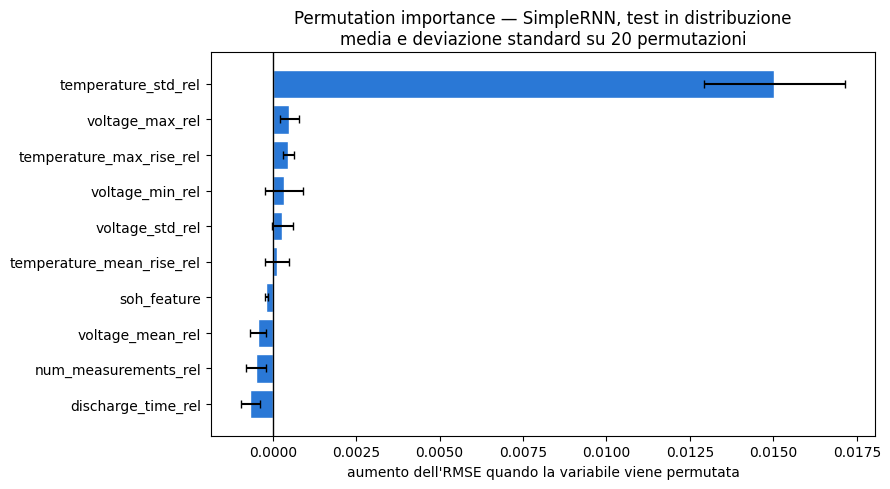

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))

tabella = importanze["test_id"].sort_values("aumento_medio")
posizioni = np.arange(len(tabella))
ax.barh(posizioni, tabella.aumento_medio, xerr=tabella.aumento_sd,
        color="#2a78d6", edgecolor="white", capsize=3)
ax.set_yticks(posizioni)
ax.set_yticklabels(tabella.variabile)
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("aumento dell'RMSE quando la variabile viene permutata")
ax.set_title(f"Permutation importance — {MODELLO_MIGLIORE}, test in distribuzione\n"
             f"media e deviazione standard su {N_PERMUTAZIONI} permutazioni")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_d2_permutation_importance.png", dpi=200, bbox_inches="tight")
plt.show()


## 9. Stadio 2 — stressore o conseguenza: il guadagno condizionale

**È il test centrale della domanda.**

Una variabile che porta informazione genuina sullo stress operativo deve aggiungere potere
predittivo **dopo** che il modello conosce già lo stato di salute corrente. Una variabile
che riflette soltanto lo stato non aggiunge nulla, perché lo stato è già dentro.

Si confrontano due modelli annidati:

$$M_0 : \text{ingressi} = \{\texttt{soh\_feature}\}, \qquad
M_1 : \text{ingressi} = \{\texttt{soh\_feature}\} \cup \{v_j\}$$

$$\text{guadagno}(j) = \mathrm{SS}(M_1) - \mathrm{SS}(M_0)$$

Il confronto deve essere **appaiato**: i guadagni attesi sono piccoli rispetto alla
variabilità fra inizializzazioni, quindi si usano gli stessi semi per $M_0$ e $M_1$ e si
applica il test dei ranghi con segno alle differenze. Confrontare due medie indipendenti
non concluderebbe nulla.

Perché questo separa causa da conseguenza e la correlazione marginale no: una conseguenza
del degrado è una funzione dello stato, quindi condizionando sullo stato la sua
informazione residua è nulla. Uno stressore è invece una causa che agisce *in aggiunta*
allo stato, e la sua informazione sopravvive al condizionamento.


In [21]:
SEMI_CONDIZIONAMENTO = [0, 1, 2, 3, 4, 5]
VARIABILI_DA_TESTARE = [c for c in FEATURE_NAMES if c != "soh_feature"]

base_condizionamento = addestra_e_valuta(
    MODELLO_MIGLIORE, ["soh_feature"], SEMI_CONDIZIONAMENTO)
base_condizionamento["configurazione"] = "M0: solo SoH"

ss_base = (base_condizionamento[base_condizionamento.insieme == "test_id"]
           .set_index("seme").SS)
print(f"M0, solo SoH — skill score mediano su test_id: {ss_base.median():.4f}")


M0, solo SoH — skill score mediano su test_id: 0.0313


In [22]:
righe_guadagno, dettaglio_guadagno = [], []

for variabile in VARIABILI_DA_TESTARE:
    esteso = addestra_e_valuta(
        MODELLO_MIGLIORE, ["soh_feature", variabile], SEMI_CONDIZIONAMENTO)
    ss_esteso = esteso[esteso.insieme == "test_id"].set_index("seme").SS

    differenze = (ss_esteso - ss_base).dropna()
    p = float(wilcoxon(differenze).pvalue) if len(differenze) >= 6 else np.nan

    righe_guadagno.append({
        "variabile": variabile,
        "SS_M0": float(ss_base.median()),
        "SS_M1": float(ss_esteso.median()),
        "guadagno_mediano": float(differenze.median()),
        "semi_con_guadagno": int((differenze > 0).sum()),
        "n_semi": len(differenze),
        "p": p,
    })
    esteso["configurazione"] = f"M0 + {variabile}"
    dettaglio_guadagno.append(esteso)

    print(f"{variabile:28s} guadagno {differenze.median():+.4f}   "
          f"favorevoli {int((differenze > 0).sum())}/{len(differenze)}   p={p:.3f}")

guadagno = pd.DataFrame(righe_guadagno).sort_values("guadagno_mediano", ascending=False)
guadagno["verdetto"] = np.where(
    (guadagno.guadagno_mediano > 0) & (guadagno.p < 0.05),
    "stressore: informazione oltre lo stato",
    "conseguenza o ridondante")

display(guadagno.round(4))
guadagno.to_csv(TABLES_DIR / "04_d2_guadagno_condizionale.csv", index=False)
pd.concat([base_condizionamento] + dettaglio_guadagno, ignore_index=True).to_csv(
    TABLES_DIR / "04_d2_guadagno_condizionale_per_seme.csv", index=False)


voltage_mean_rel             guadagno -0.0020   favorevoli 3/6   p=0.844
voltage_min_rel              guadagno -0.0634   favorevoli 2/6   p=0.562
voltage_max_rel              guadagno +0.0292   favorevoli 5/6   p=0.156
voltage_std_rel              guadagno -0.0241   favorevoli 2/6   p=0.438
temperature_mean_rise_rel    guadagno -0.0196   favorevoli 2/6   p=0.562
temperature_max_rise_rel     guadagno -0.0007   favorevoli 3/6   p=1.000
temperature_std_rel          guadagno -0.0155   favorevoli 3/6   p=0.688
discharge_time_rel           guadagno -0.0023   favorevoli 3/6   p=0.844
num_measurements_rel         guadagno -0.1378   favorevoli 1/6   p=0.219


,variabile,SS_M0,SS_M1,guadagno_mediano,semi_con_guadagno,n_semi,p,verdetto
2,voltage_max_rel,0.0313,0.0431,0.0292,5,6,0.1562,conseguenza o ridondante
5,temperature_max_rise_rel,0.0313,0.0306,-0.0007,3,6,1.0000,conseguenza o ridondante
0,voltage_mean_rel,0.0313,0.0161,-0.0020,3,6,0.8438,conseguenza o ridondante
7,discharge_time_rel,0.0313,0.0290,-0.0023,3,6,0.8438,conseguenza o ridondante
6,temperature_std_rel,0.0313,0.0165,-0.0155,3,6,0.6875,conseguenza o ridondante
4,temperature_mean_rise_rel,0.0313,0.0127,-0.0196,2,6,0.5625,conseguenza o ridondante
3,voltage_std_rel,0.0313,0.0127,-0.0241,2,6,0.4375,conseguenza o ridondante
1,voltage_min_rel,0.0313,-0.0096,-0.0634,2,6,0.5625,conseguenza o ridondante
8,num_measurements_rel,0.0313,-0.0953,-0.1378,1,6,0.2188,conseguenza o ridondante


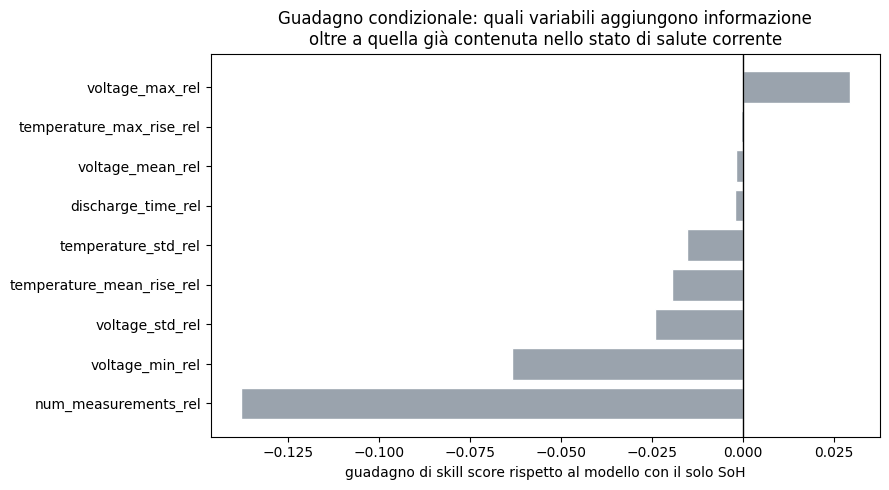

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))

ordinato = guadagno.sort_values("guadagno_mediano")
colori = np.where(ordinato.verdetto.str.startswith("stressore"), "#2a9d5c", "#9aa3ad")
posizioni = np.arange(len(ordinato))
ax.barh(posizioni, ordinato.guadagno_mediano, color=colori, edgecolor="white")
ax.set_yticks(posizioni)
ax.set_yticklabels(ordinato.variabile)
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("guadagno di skill score rispetto al modello con il solo SoH")
ax.set_title("Guadagno condizionale: quali variabili aggiungono informazione\n"
             "oltre a quella già contenuta nello stato di salute corrente")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_d2_guadagno_condizionale.png", dpi=200, bbox_inches="tight")
plt.show()


### Confronto con lo screening marginale

Lo stesso insieme di variabili, valutato con la correlazione marginale con il SoH. Serve a
mostrare che le due procedure ordinano le variabili in modo diverso, e che una variabile
può essere fortemente correlata al degrado e non portarne alcuna informazione causale.


In [24]:
colonne_disponibili = [c for c in VARIABILI_DA_TESTARE if c in validi.columns]

marginale = pd.DataFrame([{
    "variabile": c,
    "correlazione_marginale": float(validi[c].corr(validi.soh)),
} for c in colonne_disponibili])

confronto_metodi = (guadagno[["variabile", "guadagno_mediano", "verdetto"]]
                    .merge(marginale, on="variabile", how="left"))
confronto_metodi["rango_marginale"] = (
    confronto_metodi.correlazione_marginale.abs().rank(ascending=False))
confronto_metodi["rango_condizionale"] = (
    confronto_metodi.guadagno_mediano.rank(ascending=False))

display(confronto_metodi.sort_values("rango_marginale").round(4))
confronto_metodi.to_csv(TABLES_DIR / "04_d2_marginale_vs_condizionale.csv", index=False)

discordanti = confronto_metodi[
    (confronto_metodi.rango_marginale <= 3)
    & (confronto_metodi.verdetto == "conseguenza o ridondante")]
if len(discordanti):
    print("\nVariabili fra le più correlate al SoH che però non superano il")
    print("condizionamento sullo stato:")
    for riga in discordanti.itertuples():
        print(f"  {riga.variabile:28s} correlazione {riga.correlazione_marginale:+.3f}, "
              f"guadagno {riga.guadagno_mediano:+.4f}")
    print("\nSu queste, uno screening marginale avrebbe concluso il contrario.")


,variabile,guadagno_mediano,verdetto,correlazione_marginale,rango_marginale,rango_condizionale
2,voltage_mean_rel,-0.0020,conseguenza o ridondante,0.9285,1.0,3.0
4,temperature_std_rel,-0.0155,conseguenza o ridondante,-0.9178,2.0,5.0
3,discharge_time_rel,-0.0023,conseguenza o ridondante,0.8746,3.0,4.0
1,temperature_max_rise_rel,-0.0007,conseguenza o ridondante,-0.6319,4.0,2.0
5,temperature_mean_rise_rel,-0.0196,conseguenza o ridondante,-0.5732,5.0,6.0
6,voltage_std_rel,-0.0241,conseguenza o ridondante,-0.4805,6.0,7.0
8,num_measurements_rel,-0.1378,conseguenza o ridondante,-0.3602,7.0,9.0
7,voltage_min_rel,-0.0634,conseguenza o ridondante,-0.1749,8.0,8.0
0,voltage_max_rel,0.0292,conseguenza o ridondante,-0.1266,9.0,1.0



Variabili fra le più correlate al SoH che però non superano il
condizionamento sullo stato:
  voltage_mean_rel             correlazione +0.928, guadagno -0.0020
  discharge_time_rel           correlazione +0.875, guadagno -0.0023
  temperature_std_rel          correlazione -0.918, guadagno -0.0155

Su queste, uno screening marginale avrebbe concluso il contrario.


## 10. Stadio 3 — direzione temporale

Secondo test, indipendente dal primo e basato su un'idea diversa: se la variabile è una
causa, il suo valore al ciclo $t$ deve predire il degrado nei cicli **successivi** meglio
di quanto il degrado nei cicli precedenti predica la variabile.

Si calcolano due correlazioni ritardate, **dentro ciascun blocco** perché fra blocchi
domina la differenza di protocollo:

$$\rho^{+}(\tau) = \operatorname{corr}\big(v(c),\ \Delta\mathrm{SoH}(c + \tau)\big),
\qquad
\rho^{-}(\tau) = \operatorname{corr}\big(\Delta\mathrm{SoH}(c),\ v(c + \tau)\big)$$

Se $\rho^{-}$ è sistematicamente più forte di $\rho^{+}$, la freccia punta nel verso
opposto a quello causale.


In [25]:
RITARDO = 5


def direzione_temporale(dati, variabile, ritardo=RITARDO):
    """Confronta la predittività in avanti e all'indietro, entro blocco."""
    avanti, indietro, blocchi_usati = [], [], 0

    for _, gruppo in dati[dati.is_valid].groupby("protocol_block"):
        gruppo = gruppo.sort_values("discharge_cycle")
        if len(gruppo) < 3 * ritardo:
            continue
        v = gruppo[variabile].to_numpy(float)
        variazione = np.diff(gruppo.soh.to_numpy(float), prepend=np.nan)

        # v(c) contro la variazione futura, e la variazione contro v futura.
        coppia_avanti = (v[:-ritardo], variazione[ritardo:])
        coppia_indietro = (variazione[:-ritardo], v[ritardo:])
        for serie, contenitore in [(coppia_avanti, avanti), (coppia_indietro, indietro)]:
            a, b = serie
            maschera = np.isfinite(a) & np.isfinite(b)
            if maschera.sum() > 5 and np.std(a[maschera]) > 0 and np.std(b[maschera]) > 0:
                contenitore.append(float(np.corrcoef(a[maschera], b[maschera])[0, 1]))
        blocchi_usati += 1

    if not avanti or not indietro:
        return None
    return {
        "variabile": variabile,
        "rho_avanti": float(np.median(avanti)),
        "rho_indietro": float(np.median(indietro)),
        "differenza": float(np.median(np.abs(avanti)) - np.median(np.abs(indietro))),
        "n_blocchi": blocchi_usati,
    }


righe_direzione = [direzione_temporale(df, c) for c in colonne_disponibili]
direzione = pd.DataFrame([r for r in righe_direzione if r])
direzione["verso"] = np.where(direzione.differenza > 0,
                              "precede il degrado", "segue il degrado")

display(direzione.round(4).sort_values("differenza", ascending=False))
direzione.to_csv(TABLES_DIR / "04_d2_direzione_temporale.csv", index=False)

print(f"\nRitardo usato: {RITARDO} cicli. Correlazioni mediane sui blocchi, non")
print("aggregate sui cicli: aggregando, la differenza fra blocchi dominerebbe.")


,variabile,rho_avanti,rho_indietro,differenza,n_blocchi,verso
2,voltage_max_rel,-0.1167,-0.1097,0.0072,12,precede il degrado
4,temperature_mean_rise_rel,0.0325,-0.0856,0.0017,12,precede il degrado
5,temperature_max_rise_rel,0.0377,-0.0486,-0.0009,12,segue il degrado
3,voltage_std_rel,0.0299,-0.0215,-0.0051,12,segue il degrado
0,voltage_mean_rel,-0.0439,0.0092,-0.0175,12,segue il degrado
1,voltage_min_rel,0.0173,-0.0084,-0.0300,12,segue il degrado
6,temperature_std_rel,0.0244,-0.0402,-0.0544,12,segue il degrado
7,discharge_time_rel,-0.0252,0.1684,-0.1683,12,segue il degrado
8,num_measurements_rel,-0.0240,0.1498,-0.1740,12,segue il degrado



Ritardo usato: 5 cicli. Correlazioni mediane sui blocchi, non
aggregate sui cicli: aggregando, la differenza fra blocchi dominerebbe.


## 11. Stadio 4 — quanto: effetto entro blocco con bootstrap

Per le variabili che superano i due test: di quanto cambia il tasso di degrado passando
dal terzile basso al terzile alto della variabile, **confrontando cicli dello stesso
blocco**.

Il vincolo di restare dentro il blocco è ciò che evita il paradosso di Simpson: una
relazione può avere un segno dentro ogni blocco e il segno opposto sull'insieme dei
blocchi, se i blocchi differiscono sistematicamente fra loro.

L'intervallo si ottiene per **bootstrap sui blocchi** e non sui cicli. I cicli dentro un
blocco non sono osservazioni indipendenti — sono una serie temporale, e valori adiacenti
sono fortemente correlati: un bootstrap sui cicli tratterebbe osservazioni correlate come
indipendenti e produrrebbe intervalli falsamente stretti.


In [26]:
N_BOOTSTRAP = 500


def effetto_terzili(dati, variabile, n_bootstrap=N_BOOTSTRAP, seme=0):
    """Differenza di variazione media del SoH fra terzile alto e basso, entro blocco."""
    per_blocco = []
    for blocco_id, gruppo in dati[dati.is_valid].groupby("protocol_block"):
        gruppo = gruppo.sort_values("discharge_cycle").copy()
        gruppo["variazione"] = np.diff(gruppo.soh.to_numpy(float), prepend=np.nan)
        gruppo = gruppo.dropna(subset=["variazione", variabile])
        if len(gruppo) < 15 or gruppo[variabile].nunique() < 3:
            continue
        soglie = gruppo[variabile].quantile([1 / 3, 2 / 3]).to_numpy()
        basso = gruppo[gruppo[variabile] <= soglie[0]].variazione.mean()
        alto = gruppo[gruppo[variabile] >= soglie[1]].variazione.mean()
        per_blocco.append({"protocol_block": blocco_id, "effetto": float(alto - basso)})

    if len(per_blocco) < 3:
        return None
    effetti = pd.DataFrame(per_blocco)

    rng = np.random.default_rng(seme)
    campioni = [effetti.effetto.iloc[rng.integers(0, len(effetti), len(effetti))].mean()
                for _ in range(n_bootstrap)]

    return {
        "variabile": variabile,
        "effetto_medio": float(effetti.effetto.mean()),
        "ic_basso": float(np.percentile(campioni, 2.5)),
        "ic_alto": float(np.percentile(campioni, 97.5)),
        "n_blocchi": len(effetti),
        "blocchi_concordi": int((np.sign(effetti.effetto)
                                 == np.sign(effetti.effetto.mean())).sum()),
    }


righe_effetto = [effetto_terzili(df, c) for c in colonne_disponibili]
effetto = pd.DataFrame([r for r in righe_effetto if r])
effetto["intervallo_esclude_zero"] = (effetto.ic_basso * effetto.ic_alto) > 0

display(effetto.round(6).sort_values("effetto_medio"))
effetto.to_csv(TABLES_DIR / "04_d2_effetto_entro_blocco.csv", index=False)

print(f"\nIntervalli al 95% da {N_BOOTSTRAP} ricampionamenti dei blocchi.")
print("L'effetto è espresso in variazione di SoH per ciclo: valori negativi indicano")
print("che il terzile alto della variabile si accompagna a un degrado più rapido.")


,variabile,effetto_medio,ic_basso,ic_alto,n_blocchi,blocchi_concordi,intervallo_esclude_zero
5,temperature_max_rise_rel,-0.001862,-0.004354,0.000250,12,6,False
6,temperature_std_rel,-0.001784,-0.003947,0.000235,12,7,False
2,voltage_max_rel,-0.001675,-0.003544,0.000112,12,9,False
4,temperature_mean_rise_rel,-0.001529,-0.003850,0.000959,12,8,False
3,voltage_std_rel,-0.001347,-0.004016,0.001250,12,6,False
0,voltage_mean_rel,-0.001046,-0.004121,0.001432,12,7,False
1,voltage_min_rel,0.000985,-0.001443,0.003409,12,8,False
8,num_measurements_rel,0.002672,0.000752,0.004477,12,7,True
7,discharge_time_rel,0.003723,0.001646,0.005566,12,9,True



Intervalli al 95% da 500 ricampionamenti dei blocchi.
L'effetto è espresso in variazione di SoH per ciclo: valori negativi indicano
che il terzile alto della variabile si accompagna a un degrado più rapido.


## 12. La risposta a D2

Le quattro evidenze vengono messe in una sola tabella. Una variabile riceve una
conclusione di stress operativo solo se **supera entrambi i test di direzione** — guadagno
condizionale positivo e significativo, e predittività in avanti maggiore che all'indietro.
Le altre vengono classificate come conseguenze del degrado o come informazione già
contenuta nello stato.


In [27]:
sintesi = (guadagno[["variabile", "guadagno_mediano", "p", "verdetto"]]
           .merge(direzione[["variabile", "differenza", "verso"]],
                  on="variabile", how="left")
           .merge(effetto[["variabile", "effetto_medio", "intervallo_esclude_zero"]],
                  on="variabile", how="left")
           .merge(importanze["test_id"][["variabile", "aumento_medio"]],
                  on="variabile", how="left"))

sintesi["conclusione"] = np.where(
    (sintesi.guadagno_mediano > 0) & (sintesi.p < 0.05)
    & (sintesi.differenza > 0),
    "stress operativo",
    np.where(sintesi.verso == "segue il degrado",
             "conseguenza del degrado",
             "informazione già nello stato"))

sintesi = sintesi.sort_values("guadagno_mediano", ascending=False)
display(sintesi.round(4))
sintesi.to_csv(TABLES_DIR / "04_d2_sintesi.csv", index=False)


,variabile,guadagno_mediano,p,verdetto,differenza,verso,effetto_medio,intervallo_esclude_zero,aumento_medio,conclusione
0,voltage_max_rel,0.0292,0.1562,conseguenza o ridondante,0.0072,precede il degrado,-0.0017,False,0.0005,informazione già nello stato
1,temperature_max_rise_rel,-0.0007,1.0000,conseguenza o ridondante,-0.0009,segue il degrado,-0.0019,False,0.0005,conseguenza del degrado
2,voltage_mean_rel,-0.0020,0.8438,conseguenza o ridondante,-0.0175,segue il degrado,-0.0010,False,-0.0004,conseguenza del degrado
3,discharge_time_rel,-0.0023,0.8438,conseguenza o ridondante,-0.1683,segue il degrado,0.0037,True,-0.0007,conseguenza del degrado
4,temperature_std_rel,-0.0155,0.6875,conseguenza o ridondante,-0.0544,segue il degrado,-0.0018,False,0.0150,conseguenza del degrado
5,temperature_mean_rise_rel,-0.0196,0.5625,conseguenza o ridondante,0.0017,precede il degrado,-0.0015,False,0.0001,informazione già nello stato
6,voltage_std_rel,-0.0241,0.4375,conseguenza o ridondante,-0.0051,segue il degrado,-0.0013,False,0.0003,conseguenza del degrado
7,voltage_min_rel,-0.0634,0.5625,conseguenza o ridondante,-0.0300,segue il degrado,0.0010,False,0.0003,conseguenza del degrado
8,num_measurements_rel,-0.1378,0.2188,conseguenza o ridondante,-0.1740,segue il degrado,0.0027,True,-0.0005,conseguenza del degrado


In [28]:
gruppo_migliore = gruppi[gruppi.finestra.str.startswith("comune")].sort_values("mediana")
piu_lento = gruppo_migliore.iloc[0]
piu_rapido = gruppo_migliore.iloc[-1]
stressori = sintesi[sintesi.conclusione == "stress operativo"].variabile.tolist()
conseguenze = sintesi[sintesi.conclusione == "conseguenza del degrado"].variabile.tolist()

print("Risposta alla domanda 2\n")
print(f"Fra i fattori di protocollo, il degrado più lento si osserva a "
      f"{piu_lento.ambiente_c:.0f} °C ({piu_lento.mediana:.1f} punti percentuali di SoH "
      f"ogni cento cicli, n = {int(piu_lento.n_blocchi)} blocchi) e il più rapido a "
      f"{piu_rapido.ambiente_c:.0f} °C ({piu_rapido.mediana:.1f}, "
      f"n = {int(piu_rapido.n_blocchi)}).")

temperature_ordinate = gruppi[gruppi.finestra.str.startswith("comune")].sort_values("ambiente_c")
valori = temperature_ordinate.mediana.to_numpy()
monotona = bool(np.all(np.diff(valori) >= 0) or np.all(np.diff(valori) <= 0))
print(f"L'andamento con la temperatura {'è monotono' if monotona else 'NON è monotono'}: "
      f"{', '.join(f'{t:.0f} °C → {v:.1f}' for t, v in zip(temperature_ordinate.ambiente_c, valori))}.")
if not monotona:
    print("Una relazione non monotona ha correlazione lineare vicina a zero o di segno")
    print("arbitrario: è la ragione per cui uno screening di correlazione non poteva")
    print("dare una risposta interpretabile su questa variabile.")

print()
print("Fra le variabili misurate dentro un blocco:")
print("  stress operativo:      ", ", ".join(stressori) if stressori else "nessuna")
print("  conseguenza del degrado:", ", ".join(conseguenze) if conseguenze else "nessuna")

print("\nLimiti dichiarati")
for i, testo in enumerate([
    f"gruppi di ampiezza minima: il più piccolo ha "
    f"{int(gruppi[gruppi.finestra.str.startswith('comune')].n_blocchi.min())} blocchi",
    "temperatura e corrente variano insieme: gli effetti non sono separabili",
    "finestre di osservazione disuguali fra i gruppi, corrette con la finestra comune",
    "studio osservazionale: si stimano associazioni, non effetti causali",
], 1):
    print(f"  {i}. {testo}")


Risposta alla domanda 2

Fra i fattori di protocollo, il degrado più lento si osserva a 24 °C (14.8 punti percentuali di SoH ogni cento cicli, n = 4 blocchi) e il più rapido a 4 °C (56.4, n = 2).
L'andamento con la temperatura NON è monotono: 4 °C → 56.4, 22 °C → 26.6, 24 °C → 14.8, 43 °C → 24.7.
Una relazione non monotona ha correlazione lineare vicina a zero o di segno
arbitrario: è la ragione per cui uno screening di correlazione non poteva
dare una risposta interpretabile su questa variabile.

Fra le variabili misurate dentro un blocco:
  stress operativo:       nessuna
  conseguenza del degrado: temperature_max_rise_rel, voltage_mean_rel, discharge_time_rel, temperature_std_rel, voltage_std_rel, voltage_min_rel, num_measurements_rel

Limiti dichiarati
  1. gruppi di ampiezza minima: il più piccolo ha 2 blocchi
  2. temperatura e corrente variano insieme: gli effetti non sono separabili
  3. finestre di osservazione disuguali fra i gruppi, corrette con la finestra comune
  4. studi

# D3 — Robustezza fuori distribuzione

> *Quanto peggiorano i modelli su batterie mai viste in training, cicliate a temperature
> ambiente diverse?*

## 13. Perché il confronto va fatto in skill score

Confrontare direttamente l'RMSE sui due insiemi di prova è fuorviante, perché **anche la
difficoltà del compito cambia**: i blocchi fuori distribuzione sono osservati per meno
cicli e coprono un intervallo di degrado più stretto, quindi la persistenza vi sbaglia di
meno. Un modello può avere RMSE più basso fuori distribuzione e stare comunque peggio
rispetto al riferimento che deve battere.

Lo skill score normalizza per la difficoltà del compito ed è quindi la grandezza corretta.


In [29]:
righe_d3 = []
for modello_nome in MODELLI:
    for insieme in ["test_id", "test_ood"]:
        sotto = metriche[(metriche.modello == modello_nome)
                         & (metriche.insieme == insieme)]
        righe_d3.append({
            "modello": modello_nome, "insieme": insieme,
            "RMSE_mediano": float(sotto.RMSE.median()),
            "SS_mediano": float(sotto.SS.median()),
            "baseline_RMSE": baseline_rmse[insieme],
        })

d3 = pd.DataFrame(righe_d3).pivot(index="modello", columns="insieme")
d3.columns = [f"{a}_{b}" for a, b in d3.columns]
d3["RMSE_sembra_migliore_ood"] = d3.RMSE_mediano_test_ood < d3.RMSE_mediano_test_id
d3["SS_davvero_migliore_ood"] = d3.SS_mediano_test_ood > d3.SS_mediano_test_id
d3["conclusioni_discordi"] = d3.RMSE_sembra_migliore_ood != d3.SS_davvero_migliore_ood

display(d3.round(4))
d3.reset_index().to_csv(TABLES_DIR / "04_d3_confronto_insiemi.csv", index=False)

discordi = int(d3.conclusioni_discordi.sum())
print(f"\nModelli su cui RMSE grezzo e skill score portano a conclusioni opposte: "
      f"{discordi} su {len(d3)}.")
print(f"La persistenza sbaglia {baseline_rmse['test_id']:.5f} in distribuzione e "
      f"{baseline_rmse['test_ood']:.5f} fuori: il compito fuori distribuzione è")
print("più facile per il riferimento, e l'RMSE grezzo non ne tiene conto.")


,RMSE_mediano_test_id,RMSE_mediano_test_ood,SS_mediano_test_id,SS_mediano_test_ood,baseline_RMSE_test_id,baseline_RMSE_test_ood,RMSE_sembra_migliore_ood,SS_davvero_migliore_ood,conclusioni_discordi
modello,,,,,,,,,
GRU,0.0331,0.0303,-8.0438,-13.3974,0.011,0.008,True,False,True
LSTM,0.0458,0.0292,-16.2809,-12.2453,0.011,0.008,True,True,False
MLP,0.1021,0.0838,-85.0449,-108.3106,0.011,0.008,True,False,True
SimpleRNN,0.0268,0.0178,-5.3404,-4.4882,0.011,0.008,True,True,False



Modelli su cui RMSE grezzo e skill score portano a conclusioni opposte: 2 su 4.
La persistenza sbaglia 0.01103 in distribuzione e 0.00804 fuori: il compito fuori distribuzione è
più facile per il riferimento, e l'RMSE grezzo non ne tiene conto.


## 14. Il confronto pulito: le stesse celle, protocollo diverso

B0042 e B0043 compaiono in entrambi gli insiemi di prova, con la prima metà della loro
vita in distribuzione e la seconda fuori. Restringendo il confronto a queste due celle, la
differenza misurata non può essere attribuita alla variabilità fra esemplari: **è
l'effetto del solo cambio di protocollo**.


In [30]:
celle_id = {b.split("_p")[0] for b in np.unique(blocco["test_id"])}
celle_ood = {b.split("_p")[0] for b in np.unique(blocco["test_ood"])}
condivise = sorted(celle_id & celle_ood)
print("Celle presenti in entrambi gli insiemi:", ", ".join(condivise) or "nessuna")

righe_pulite = []
for modello_nome in predizioni.modello.unique():
    sotto = predizioni[predizioni.modello == modello_nome].copy()
    if "protocol_block" in sotto.columns:
        cella = sotto.protocol_block.str.split("_p").str[0]
    else:
        cella = sotto.battery_id
    for insieme in ["test_id", "test_ood"]:
        selezione = sotto[(sotto.insieme == insieme) & cella.isin(condivise)]
        if not len(selezione):
            continue
        righe_pulite.append({
            "modello": modello_nome, "insieme": insieme,
            "n_finestre": len(selezione),
            "RMSE": rmse(selezione.soh_vero, selezione.soh_previsto),
            "SS": skill_score(selezione.soh_vero, selezione.soh_previsto,
                              selezione.soh_baseline),
        })

confronto_pulito = pd.DataFrame(righe_pulite)
if len(confronto_pulito):
    tabella = confronto_pulito.pivot(index="modello", columns="insieme",
                                     values=["RMSE", "SS", "n_finestre"])
    tabella.columns = [f"{a}_{b}" for a, b in tabella.columns]
    tabella["perdita_di_SS"] = tabella.SS_test_id - tabella.SS_test_ood
    display(tabella.round(4))
    tabella.reset_index().to_csv(TABLES_DIR / "04_d3_stesse_celle.csv", index=False)
else:
    print("Nessuna cella condivisa fra i due insiemi: il confronto pulito non è possibile.")


Celle presenti in entrambi gli insiemi: B0042, B0043


,RMSE_test_id,RMSE_test_ood,SS_test_id,SS_test_ood,n_finestre_test_id,n_finestre_test_ood,perdita_di_SS
modello,,,,,,,
Baseline persistenza,0.0052,0.0070,0.0000,0.0000,50.0,30.0,0.0000
GRU,0.0163,0.0155,-8.7571,-3.9132,50.0,30.0,-4.8439
LSTM,0.0298,0.0214,-31.5172,-8.2921,50.0,30.0,-23.2251
MLP,0.0354,0.0811,-44.8170,-132.9101,50.0,30.0,88.0931
SimpleRNN,0.0046,0.0056,0.2389,0.3551,50.0,30.0,-0.1162


## 15. Quanto si sono spostati gli ingressi

Il degrado di prestazioni va messo in relazione con quanto le condizioni operative
differiscono davvero. Gli ingressi sono già normalizzati e limitati a cinque deviazioni
standard, quindi si riporta la distanza fra le distribuzioni: differenza di media per
variabile, in unità di deviazione standard dell'addestramento.


In [31]:
scostamenti = []
media_train = X["train"].reshape(-1, len(FEATURE_NAMES)).mean(axis=0)
sd_train = X["train"].reshape(-1, len(FEATURE_NAMES)).std(axis=0)

for insieme in ["validation", "test_id", "test_ood"]:
    piatto = X[insieme].reshape(-1, len(FEATURE_NAMES))
    for j, nome_variabile in enumerate(FEATURE_NAMES):
        if sd_train[j] < 1e-9:
            continue
        scostamenti.append({
            "insieme": insieme, "variabile": nome_variabile,
            "differenza_medie_sd": float((piatto[:, j].mean() - media_train[j]) / sd_train[j]),
            "rapporto_dispersioni": float(piatto[:, j].std() / sd_train[j]),
        })

scostamenti = pd.DataFrame(scostamenti)
sintesi_scostamenti = (scostamenti.assign(modulo=scostamenti.differenza_medie_sd.abs())
                       .groupby("insieme")
                       .agg(scostamento_medio=("modulo", "mean"),
                            scostamento_massimo=("modulo", "max"),
                            variabile_peggiore=("modulo", "idxmax"))
                       .reset_index())
sintesi_scostamenti["variabile_peggiore"] = (
    scostamenti.loc[sintesi_scostamenti.variabile_peggiore, "variabile"].to_numpy())

display(sintesi_scostamenti.round(3))
scostamenti.to_csv(TABLES_DIR / "04_d3_scostamento_ingressi.csv", index=False)


,insieme,scostamento_medio,scostamento_massimo,variabile_peggiore
0,test_id,0.872,2.796,num_measurements_rel
1,test_ood,0.974,2.327,num_measurements_rel
2,validation,0.688,1.812,voltage_std_rel


In [32]:
print("Risposta alla domanda 3\n")
for riga in d3.reset_index().itertuples():
    print(f"{riga.modello:12s} skill score {riga.SS_mediano_test_id:8.2f} in "
          f"distribuzione → {riga.SS_mediano_test_ood:8.2f} fuori")

print()
if discordi:
    print(f"Su {discordi} modelli su {len(d3)}, l'RMSE grezzo suggerirebbe che il")
    print("comportamento fuori distribuzione sia migliore. Lo skill score mostra che non")
    print("lo è: il riferimento naive sbaglia di meno su quell'insieme, quindi la stessa")
    print("prestazione assoluta corrisponde a una prestazione relativa peggiore.")

print()
print("Il limite resta il confondimento fra temperatura e corrente: quello che si misura")
print("è la perdita di prestazioni dovuta al cambio di protocollo nel suo complesso, e")
print("non l'effetto della sola temperatura.")


Risposta alla domanda 3

GRU          skill score    -8.04 in distribuzione →   -13.40 fuori
LSTM         skill score   -16.28 in distribuzione →   -12.25 fuori
MLP          skill score   -85.04 in distribuzione →  -108.31 fuori
SimpleRNN    skill score    -5.34 in distribuzione →    -4.49 fuori

Su 2 modelli su 4, l'RMSE grezzo suggerirebbe che il
comportamento fuori distribuzione sia migliore. Lo skill score mostra che non
lo è: il riferimento naive sbaglia di meno su quell'insieme, quindi la stessa
prestazione assoluta corrisponde a una prestazione relativa peggiore.

Il limite resta il confondimento fra temperatura e corrente: quello che si misura
è la perdita di prestazioni dovuta al cambio di protocollo nel suo complesso, e
non l'effetto della sola temperatura.


## 16. Riepilogo dei file prodotti


In [33]:
prodotti = sorted(list(TABLES_DIR.glob("04_*.csv")) + list(FIGURES_DIR.glob("04_*.png")))
for percorso in prodotti:
    print("  ", percorso.relative_to(PROJECT_ROOT))
print(f"\n{len(prodotti)} file prodotti da questo notebook.")
print("\nNotebook supplementari: 05_experiment_data_scaling, 06_experiment_horizon, "
      "07_experiment_rul.")


   results/figures/04_d1_distribuzione_errore.png
   results/figures/04_d2_guadagno_condizionale.png
   results/figures/04_d2_permutation_importance.png
   results/figures/04_d2_tasso_degrado.png
   results/tables/04_d1_ablazione.csv
   results/tables/04_d1_ablazione_per_seme.csv
   results/tables/04_d1_baseline.csv
   results/tables/04_d1_confronti_appaiati.csv
   results/tables/04_d1_riepilogo_test_id.csv
   results/tables/04_d2_direzione_temporale.csv
   results/tables/04_d2_effetto_entro_blocco.csv
   results/tables/04_d2_guadagno_condizionale.csv
   results/tables/04_d2_guadagno_condizionale_per_seme.csv
   results/tables/04_d2_marginale_vs_condizionale.csv
   results/tables/04_d2_permutation_importance.csv
   results/tables/04_d2_sintesi.csv
   results/tables/04_d2_tasso_degrado_per_blocco.csv
   results/tables/04_d2_tasso_degrado_per_gruppo.csv
   results/tables/04_d2_unita_di_analisi.csv
   results/tables/04_d3_confronto_insiemi.csv
   results/tables/04_d3_scostamento_ingressi.